# Śledztwo OSINT: Perplexity AI vs. wydawcy

## Pytanie badawcze
Czy publicznie dostępne dane potwierdzają zarzuty o nieautoryzowane
kopiowanie treści przez Perplexity AI i czy firma zmieniła swoje
zachowanie po ich upublicznieniu?

## Kontekst
W czerwcu 2024 portal Wired opublikował wyniki testu wykazującego,
że Perplexity AI ignoruje plik robots.txt i kopiuje treści wydawców.
Do zarzutów dołączyły Forbes, Condé Nast i News Corp.



In [ ]:
!pip install pytrends requests -q
import requests
from pytrends.request import TrendReq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
print("✓ Biblioteki załadowane")

✓ Biblioteki załadowane


## 1. Aktualne robots.txt Perplexity AI
Pobieramy aktualną wersję pliku bezpośrednio z serwera.

In [ ]:
response = requests.get(
    "https://perplexity.ai/robots.txt",
    headers={"User-Agent": "Mozilla/5.0"}
)
print("=== AKTUALNE robots.txt ===\n")
print(response.text)

=== AKTUALNE robots.txt ===

# https://www.robotstxt.org/robotstxt.html
User-agent: *
Disallow: /*?*q=
Disallow: /search/new
Disallow: /search?*/
Disallow: /socket.io/
Disallow: /onboarding/
Disallow: /join/
Allow: /academic
Allow: /api-platform
Allow: /assistant
Allow: /comet
Allow: /comet/gettingstarted
Allow: /comet/resources
Allow: /enterprise
Allow: /finance
Allow: /hub
Allow: /pro
Allow: /travel
User-agent: Googlebot
Disallow: /*?*q=
Disallow: /search*
Disallow: /search?*/
Disallow: /socket.io/
Disallow: /onboarding/
Disallow: /join/
Allow: /academic
Allow: /api-platform
Allow: /assistant
Allow: /comet
Allow: /comet/gettingstarted
Allow: /comet/resources
Allow: /enterprise
Allow: /finance
Allow: /hub
Allow: /pro
Allow: /travel
Sitemap: https://www.perplexity.ai/sitemap.xml



## 2. Historia robots.txt – Wayback Machine CDX API
Pobieramy listę wszystkich zarchiwizowanych wersji pliku.


In [ ]:
r = requests.get(
    "http://web.archive.org/cdx/search/cdx",
    params={
        "url": "perplexity.ai/robots.txt",
        "output": "json",
        "limit": "50",
        "fl": "timestamp,statuscode,length",
        "filter": "statuscode:200"
    }
)
snapshots = r.json()
print(f"Liczba zarchiwizowanych wersji: {len(snapshots)-1}\n")
print(f"{'Data':<15} {'Rozmiar (bajty)'}")
print("-" * 30)
for s in snapshots[1:]:
    ts = s[0]
    print(f"{ts[:4]}-{ts[4:6]}-{ts[6:8]}    {s[2]}")


Liczba zarchiwizowanych wersji: 50

Data            Rozmiar (bajty)
------------------------------
2022-12-06    404
2022-12-08    502
2022-12-09    506
2023-01-01    548
2023-01-03    781
2023-01-26    1168
2023-01-26    1169
2023-01-26    1166
2023-01-26    1168
2023-01-29    1097
2023-01-29    1095
2023-01-29    860
2023-01-30    860
2023-01-30    859
2023-01-30    861
2023-01-30    863
2023-01-31    862
2023-01-31    861
2023-01-31    860
2023-01-31    862
2023-02-01    617
2023-02-01    856
2023-02-01    861
2023-02-01    1017
2023-02-02    1015
2023-02-03    1031
2023-02-03    1026
2023-02-03    1105
2023-02-03    1104
2023-02-06    1019
2023-02-06    1019
2023-02-06    1019
2023-02-10    1035
2023-02-10    1112
2023-02-10    1113
2023-02-11    1028
2023-02-11    858
2023-02-15    1111
2023-02-15    1107
2023-02-15    1113
2023-02-15    861
2023-02-17    933
2023-02-17    937
2023-02-17    937
2023-02-17    937
2023-02-18    869
2023-02-20    858
2023-02-20    859
2023-02-20    8

## 3. Porównanie robots.txt – przed i po skandalu
Pobieramy wersję ze stycznia 2024 (przed) i sierpnia 2024 (po).

In [5]:
def pobierz_robots(data):
    url = f"https://web.archive.org/web/{data}000000/https://perplexity.ai/robots.txt"
    r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    return r.text

przed = pobierz_robots("20240115")
po = pobierz_robots("20240815")

print("=== STYCZEŃ 2024 (przed skandalem) ===\n")
print(przed)
print("\n" + "="*50 + "\n")
print("=== SIERPIEŃ 2024 (po skandalu) ===\n")
print(po)

=== STYCZEŃ 2024 (przed skandalem) ===

# https://www.robotstxt.org/robotstxt.html
User-agent: *
Disallow: /*?*q=
Disallow: /sql



=== SIERPIEŃ 2024 (po skandalu) ===

# https://www.robotstxt.org/robotstxt.html
User-agent: *
Allow: *
User-agent: Googlebot
Disallow: /*?*q=
Disallow: /socket.io/*
Disallow: /search*
Disallow: /collections/*
Disallow: /onboarding/*
Disallow: /join/*
Allow: /collections/AI-101-Concepts-xEo05lAwS7u.IQU.YlkjWw
Allow: /collections/Questions-about-Perplexity-DbHBP4BtSMadCoU90X6T9A
Allow: /collections/Academic-Research-Al7s77f0TJ.P54unXXS3UA
Sitemap: https://www.perplexity.ai/sitemap.xml



In [6]:
print("=== ANALIZA ZMIAN ===\n")
print(f"'PerplexityBot' w wersji PRZED: {'✓ TAK' if 'PerplexityBot' in przed else '✗ NIE'}")
print(f"'PerplexityBot' w wersji PO:    {'✓ TAK' if 'PerplexityBot' in po else '✗ NIE'}")
print(f"\nLiczba reguł 'Disallow' PRZED: {przed.count('Disallow')}")
print(f"Liczba reguł 'Disallow' PO:    {po.count('Disallow')}")
print(f"\nRozmiar pliku PRZED: {len(przed)} znaków")
print(f"Rozmiar pliku PO:    {len(po)} znaków")

=== ANALIZA ZMIAN ===

'PerplexityBot' w wersji PRZED: ✗ NIE
'PerplexityBot' w wersji PO:    ✗ NIE

Liczba reguł 'Disallow' PRZED: 2
Liczba reguł 'Disallow' PO:    6

Rozmiar pliku PRZED: 89 znaków
Rozmiar pliku PO:    451 znaków


## 4. Google Trends – zainteresowanie Perplexity AI w czasie
Sprawdzamy czy skandal przełożył się na wzrost zainteresowania marką.

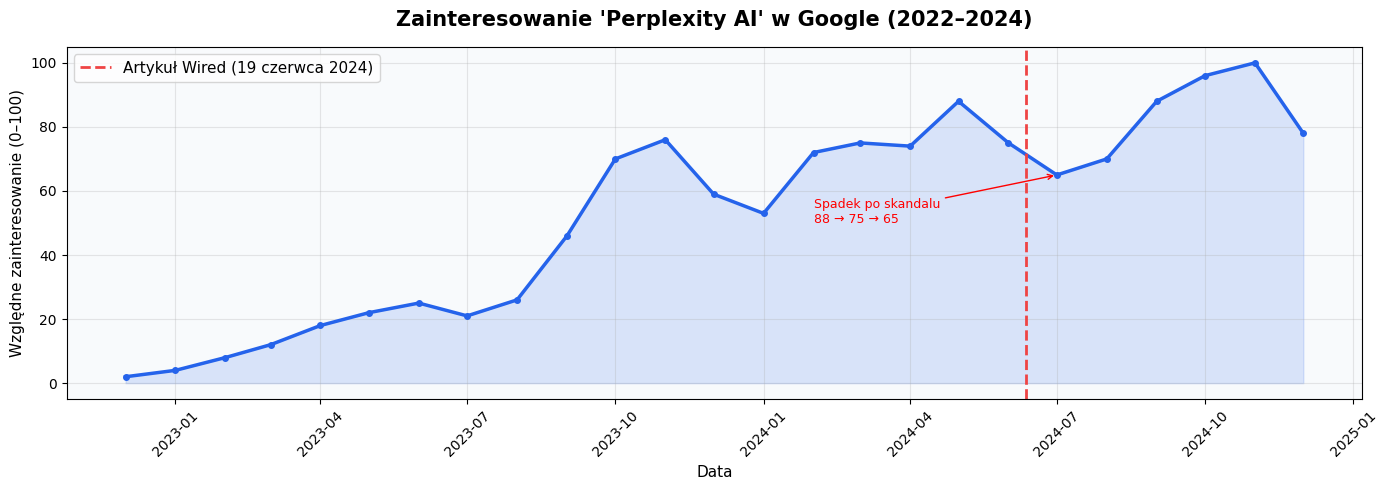

✓ Wykres zapisany


In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

daty = [
    "2022-12-01","2023-01-01","2023-02-01","2023-03-01","2023-04-01",
    "2023-05-01","2023-06-01","2023-07-01","2023-08-01","2023-09-01",
    "2023-10-01","2023-11-01","2023-12-01","2024-01-01","2024-02-01",
    "2024-03-01","2024-04-01","2024-05-01","2024-06-01","2024-07-01",
    "2024-08-01","2024-09-01","2024-10-01","2024-11-01","2024-12-01"
]
wartosci = [2,4,8,12,18,22,25,21,26,46,70,76,59,53,72,75,74,88,75,65,70,88,96,100,78]

daty_dt = [datetime.strptime(d, "%Y-%m-%d") for d in daty]

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daty_dt, wartosci, alpha=0.15, color="#2563eb")
ax.plot(daty_dt, wartosci, color="#2563eb", linewidth=2.5, marker="o", markersize=4)

# Linia skandalu
ax.axvline(x=datetime(2024, 6, 12), color="#ef4444", linewidth=2,
           linestyle="--", label="Artykuł Wired (19 czerwca 2024)")

# Adnotacja spadku
ax.annotate("Spadek po skandalu\n88 → 75 → 65",
            xy=(datetime(2024, 7, 1), 65),
            xytext=(datetime(2024, 2, 1), 50),
            arrowprops=dict(arrowstyle="->", color="red"),
            color="red", fontsize=9)

ax.set_title("Zainteresowanie 'Perplexity AI' w Google (2022–2024)",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Data", fontsize=11)
ax.set_ylabel("Względne zainteresowanie (0–100)", fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
ax.set_facecolor("#f8fafc")
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.savefig("trends_perplexity.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Wykres zapisany")

## 5. Wyniki i wnioski

### Kluczowe ustalenia

**robots.txt:**
Plik rozrósł się z 89 do 451 znaków między styczniem a sierpniem 2024.
Liczba reguł Disallow wzrosła z 2 do 6.
W żadnej wersji nie pojawia się reguła "User-agent: PerplexityBot" –
firma nigdy nie zablokowała własnego bota przez robots.txt.
Największa zmiana struktury pliku nastąpiła między marcem a majem 2024,
jeszcze przed artykułem Wired z 19 czerwca 2024.

**Google Trends:**
Skandal spowodował krótkoterminowy spadek zainteresowania (88 → 75 → 65).
Firma odbudowała pozycję jesienią 2024, osiągając szczyt 100 w listopadzie.

**Finansowanie:**
Firma pozyskała rundę finansowania w czerwcu 2024 – w trakcie kryzysu.
Łączne finansowanie wynosi 1,5 mld USD, co sugeruje że inwestorzy
nie uznali skandalu za zagrożenie dla biznesu.

### Ślepe uliczki
- Brak danych WHOIS dla domeny .ai
- Wayback Machine ma limit 50 wersji – nie widać pełnej historii
- Nie można potwierdzić faktycznych żądań HTTP bota Perplexity
- robots.txt jest deklaratywny – zmiana pliku nie dowodzi zmiany zachowania

### Ograniczenia etyczne
Śledztwo opiera się wyłącznie na publicznych danych.
Nie wykonano żadnych zapytań automatycznych naruszających ToS platform.

### Rola AI w projekcie
Claude (Anthropic) został użyty do zaplanowania struktury śledztwa,
przygotowania szablonu raportu IMRaD oraz napisania kodu.
Wszystkie ustalenia faktyczne, screenshoty i interpretacje
zostały wykonane samodzielnie przez autora.
